# Compare O2 from discrete winkler samples, shipboard ctd rosette (Seabird SBE43), and RCA DOFSTA302 (Seabird SBE43)

In [1]:
# Import libraries
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from io import StringIO

## Import discrete sample data (Winkler calculation spreadsheet) 

In [2]:
# Import winkler excel sheet locally

df_wink = pd.read_excel(
    './data/Winkler_calculations_19aug25AT50-41.xls',  
    usecols = 'J,AM', # Select only columns of interest (depth and oxygen concentration)
    skiprows=15, # Select rows of insterest eg:skip first 15 rows (i.e. start from row 16)
    nrows=16, # Read next 16 rows (16 to 31 inclusive)
    header=None, 
    names=['Depth_wink','O2_wink']
)

df_wink[0:5]  #check values

,Depth_wink,O2_wink
0,201,132.375314
1,201,132.025561
2,162,145.511525
3,162,146.258664
4,122,209.775586


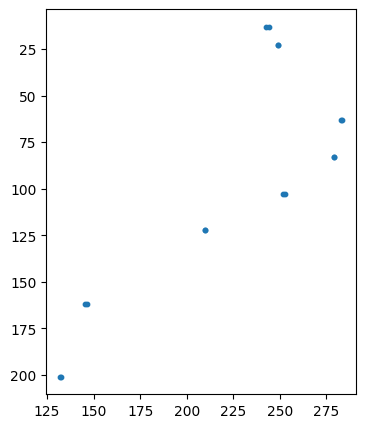

In [3]:
# Optional: plot winkler data to check
plt.figure(figsize=[4, 5])
plt.scatter(df_wink.O2_wink,df_wink.Depth_wink, s=10)

plt.gca().invert_yaxis()

## Import calibration CTD file (cnv)

In [4]:
# import ctd cnv file locally

datafile_ctd = './data/AT50-41_CTD-007.cnv' 

# Load in cruise data file without header and including variable names from file

with open(datafile_ctd,'r') as  cruise_data:
    lines = cruise_data.readlines()
    
# 1.Find data start point
for i, line in enumerate(lines):
    if line.strip().startswith('*END*'):
        data_start = i + 1
        break

# 2.Extract variable names from lines like: "# name 0 = t90C: Temperature [C]"
column_names = []
for line in lines:
    if line.strip().startswith('# name'):
        # Extract the part after '=' amd before the colon (or take full if no colon)
        match = re.search(r'# name \d+ = ([^:]+)', line)
        if match:
            name = match.group(1).strip()
            column_names.append(name)

# 3.Read the data section into data frame
data_str = ''.join(lines[data_start:])
df_ctd = pd.read_csv(StringIO(data_str), sep=r'\s+', header=None)

# 4.Assign column names 
df_ctd.columns = column_names[:df_ctd.shape[1]] # Trim of mismatch

# 5. optional: show first few rows
print(df_ctd.head())


   modError   prDM  depSM  latitude  timeS    t090C    t190C   prDM  \
0         0  3.341  3.314  45.83344  0.000  17.8460  17.8442  3.341   
1         0  3.357  3.330  45.83344  0.042  17.8457  17.8442  3.357   
2         0  3.341  3.314  45.83344  0.083  17.8458  17.8442  3.341   
3         0  3.341  3.314  45.83344  0.125  17.8458  17.8442  3.341   
4         0  3.341  3.314  45.83344  0.167  17.8458  17.8442  3.341   

   sbeox0Mm/L  flag  
0     243.146   0.0  
1     243.148   0.0  
2     243.147   0.0  
3     243.147   0.0  
4     243.147   0.0  


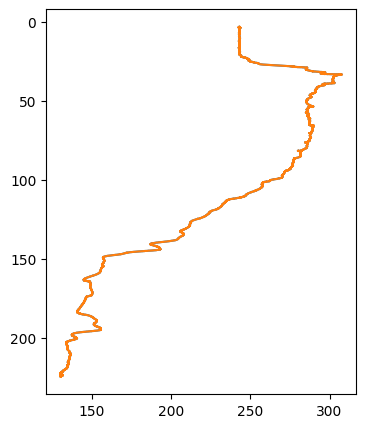

In [5]:
# Optional: plot ctd data to check
plt.figure(figsize=[4, 5])
plt.plot(df_ctd["sbeox0Mm/L"],df_ctd["prDM"],'-')

plt.gca().invert_yaxis()

## Import DOFSTA file (netcdf)

In [6]:
# Load nc file, switch dimensions

localFile = './data/deployment0011_RS03AXPS-SF03A-2A-DOFSTA302-streamed-do_fast_sample_20250818T154501.784469-20250818T173000.948881.nc' 
siteData = xr.open_dataset(localFile).load()

siteData = siteData.swap_dims({'obs': 'time'})


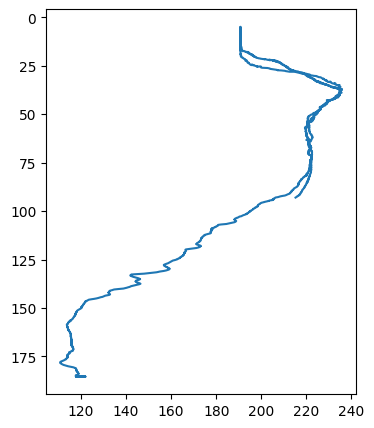

In [7]:
# Optional: plot DOFSTA data to check
plt.figure(figsize=[4, 5])
plt.plot(siteData['corrected_dissolved_oxygen'],siteData['depth'],)

plt.gca().invert_yaxis()

## O2 comparison plot from discrete samples, ctd calibration cast, and DOFTSA

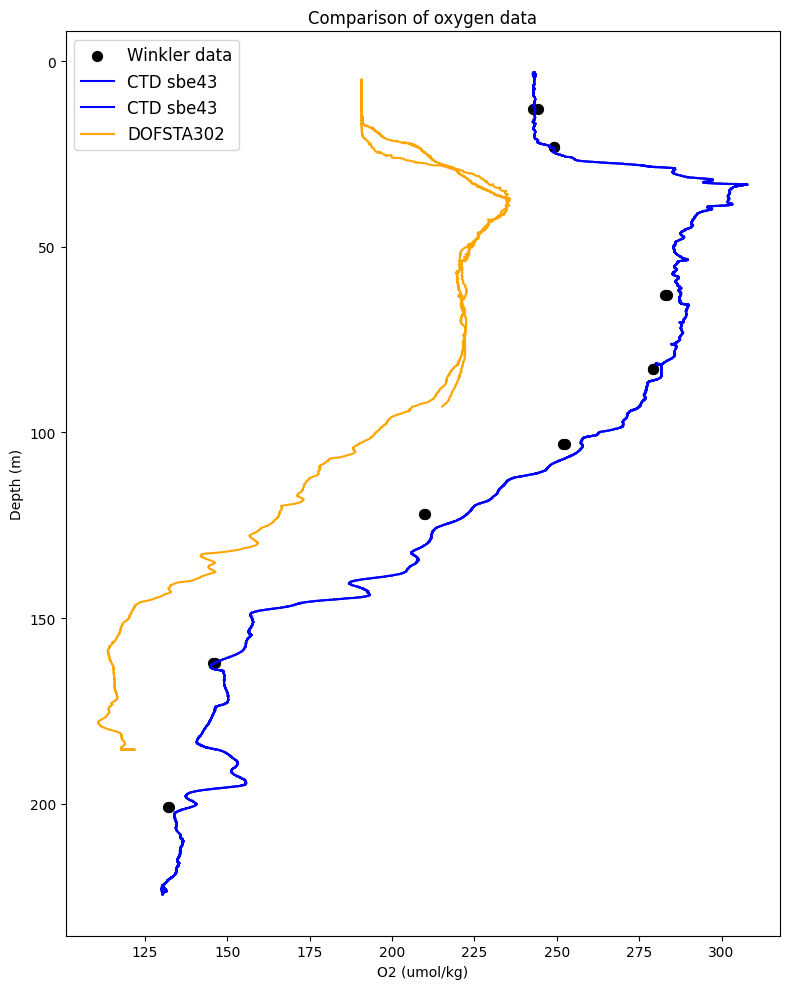

In [8]:
plt.figure(figsize=[8, 10])

# Plot winkler
plt.scatter(df_wink.O2_wink,df_wink.Depth_wink, label="Winkler data", color="black",s=50)

# Plot ctd
plt.plot(df_ctd["sbeox0Mm/L"],df_ctd["prDM"], label="CTD sbe43", color="blue")

# Plot DOFSTA
plt.plot(siteData['corrected_dissolved_oxygen'],siteData['depth'], label="DOFSTA302", color="orange")

plt.gca().invert_yaxis()

# Set labels and title
plt.xlabel("O2 (umol/kg)")
plt.ylabel("Depth (m)")
plt.title("Comparison of oxygen data") #example

# Add legend
plt.legend(loc="upper left", fontsize=12)

# Show and save plot
plt.tight_layout()
plt.savefig("./output/O2_comp.png") #example
plt.show()      